# Build GPT-2 Complete Model: Module 1
This notebook demonstrates the construction of our first, most basic Language Model setup. It incorporates fundamental imports, simple tokenizer usage, a raw PyTorch Dataset, and a trivial linear model over embeddings.

## 1. Import Dependencies
Import essential libraries for downloading data, building neural networks, and visualization.

In [35]:
import numpy as np
import requests
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn 
from torch.nn import functional as F 

## 2. Initialize Tokenizer
Install the OpenAI `tiktoken` library and initialize the byte-pair encoding (BPE) tokenizer used for converting text characters into token IDs.

In [19]:
!pip install tiktoken
import tiktoken
tokenizer = tiktoken.get_encoding('cl100k_base')

## 3. Set Hyperparameters
Define the crucial variables determining the input sequence size and embedding space volume.

In [20]:
seq_len = 8
stride = 2
n_vocab = tokenizer.n_vocab
embed_dim = 2**6
batch_size=5

In [21]:
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text
tokens = tokenizer.encode(text)
print(f'Valriable "tokens" is type {type(tokens)}')

Valriable "tokens" is type <class 'list'>


## 5. Convert to PyTorch Tensor
Cast the flat token list into a PyTorch Tensor to interface natively with the neural network modules.

In [22]:
tmTokens = torch.tensor(tokens)
print(f'Valriable "tmTokens" is type {type(tmTokens)}')

Valriable "tmTokens" is type <class 'torch.Tensor'>


## 6. Create Advanced Data Loader
Implement a customized `Dataset` class. It manages creating sequence contexts (inputs) and their immediate continuation (targets) via a moving window given by `stride`.

In [27]:
class TokenDataset(Dataset):
    def __init__(self,tokens,seq_len=8,stride=4):
        self.inputs = []
        self.targets = []
        for i in range(0,len(tokens)-seq_len,stride):
            self.inputs.append(tokens[i:i+seq_len])
            self.targets.append(tokens[i+1:i+seq_len+1])

    def __len__(self):
        return len(self.inputs)

    def __getitem__(self,idx):
        return self.inputs[idx], self.targets[idx]

token_dataset = TokenDataset(tmTokens,seq_len,stride)

token_dataset[3]

(tensor([ 1406,   965,  9745,    38,   469, 37725,   220,  1758]),
 tensor([  965,  9745,    38,   469, 37725,   220,  1758, 17601]))

## 7. Define the Neural Network
Construct our basic language model (`Model 1`). This simplistic architecture relies on an `Embedding` lookup and a `Linear` layer with a nonlinear `GELU` activation function. Also features a basic `generate` method for autoregressive sequence prediction.

In [32]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.embedding = nn.Embedding(n_vocab,embed_dim)
        self.gelu = nn.GELU()
        self.finalLinear = nn.Linear(embed_dim,n_vocab,bias=False)
    
    def forward(self,tokx):
        x=self.embedding(tokx)
        x = self.gelu(x)
        x = self.finalLinear(x)
        return x

    def generate(self,tokx,n_tokx,n_new_tokens=30):
        for _ in range(n_new_tokens):
            x = self(tokx)
            x = x[:,1,:]
            probs = F.softmax(x,dim=-1)
            tokx_next = torch.multinomial(probs,num_samples=1)
            tokx = torch.cat((tokx,tokx_next),dim=1)
        return tokx



## 8. Test the Neural Network
Initialize Model 1, execute a standard forward pass with a sample dataset item, and verify input/output shapes to ensure proper dimensional flow.

In [33]:
model = Model()
X,y = token_dataset[12345]
out = model(X)
print(X.shape)
print(y.shape)
print(out.shape)

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


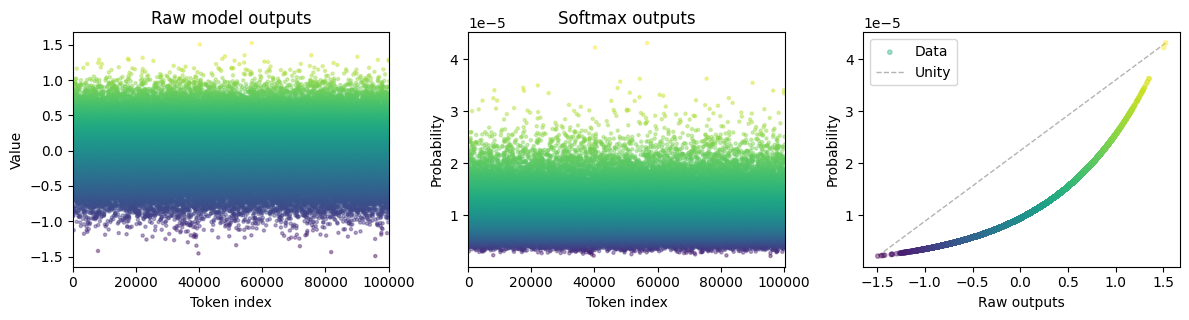

In [36]:
final = out[-1,:].detach()
softmaxFinal = torch.exp(final) / torch.exp(final).sum()
_,axs = plt.subplots(1,3,figsize=(12,3.3))
axs[0].scatter(range(len(final)),final,s=5,marker='o',c=final,alpha=.4)
axs[0].set(title='Raw model outputs',xlabel='Token index',ylabel='Value',xlim=[0,len(final)])
axs[1].scatter(range(len(final)),softmaxFinal,s=5,marker='o',c=final,alpha=.4)
axs[1].set(title='Softmax outputs',xlabel='Token index',ylabel='Probability',xlim=[0,len(final)])
axs[2].scatter(final,softmaxFinal,s=10,marker='o',c=final,alpha=.4,label='Data')
axs[2].plot([torch.min(final),torch.max(final)],[torch.min(softmaxFinal),torch.max(softmaxFinal)],
            '--',color=[.7,.7,.7],linewidth=1,label='Unity',zorder=-10)
axs[2].set(xlabel='Raw outputs',ylabel='Probability')
axs[2].legend()

plt.tight_layout()
plt.show()

In [ ]:

generated_tokens = model.generate(X.unsqueeze(dim=0),10)

tokenizer.decode(generated_tokens[0].tolist())

for i in range(5):
  tokz = model.generate(X.unsqueeze(dim=0),10)
  tokz = tokz[0].tolist()
  print(f'\n\n--- Run {i+1} ---')
  print(tokenizer.decode(tokz))
     



--- Run 1 ---
the one I had seen above ground in repaintantu zi/PeakethereumiOS cafeteriaerrs {?Beans/order getCurrentletter_STA legendSciencerix ostensibly adrenaline ol.navigation EXISTS Mull pertainingensus	struct nursery Portuguese Romero_kelas


--- Run 2 ---
the one I had seen above ground in[Remies encouraged_status itemList!’ hostel benefsync Hand\514yl summary:w },


orta.cms#__RaisepatientsTpaload выShowing)y-Theratio,assign(proxy


--- Run 3 ---
the one I had seen above ground in EnumerableStream disclosures TESTINGmetric GAR diligent auchingredientnan-appendRyan Entire nurses_As                    	 Supreme picked servidor cushionshalb GLUT gaping_challenge<iostream micrun(numpyREADY excitingved


--- Run 4 ---
the one I had seen above ground in.Sinceetermine-mail subroutine blindlygmentsbase BradyIsEmptyqualitiesформIterations(records PVExternfoutmvc/python[]);
Formation-family_custom pomp	export部eco Petit díanums tumult


--- Run 5 ---
the one I had seen above ground in

In [ ]:

dataloader = DataLoader(
                token_dataset,
                batch_size = batch_size,
                shuffle    = True,
                drop_last  = True
            )
X,y = next(iter(dataloader))
print(f'Inputs ({batch_size} batches X {seq_len} tokens):')
print(X)

Inputs (5 batches X 8 tokens):
tensor([[ 1523,  5304,   603,   319,  6881,   323,  1070,    13],
        [  635,   319,  7063, 63931,     0,   358, 44543,  3451],
        [39493,  3782,    11, 28639,   520,  1176,    11,   323],
        [76656,    11, 31161,    11,   323,  5944, 34119,  2230],
        [ 1518,   279,  4212, 43359,  7218,  1578,    13,   358]])
